<a href="https://colab.research.google.com/github/laiba2023/DataSeekho/blob/DSMP_Module2/final_project_module2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

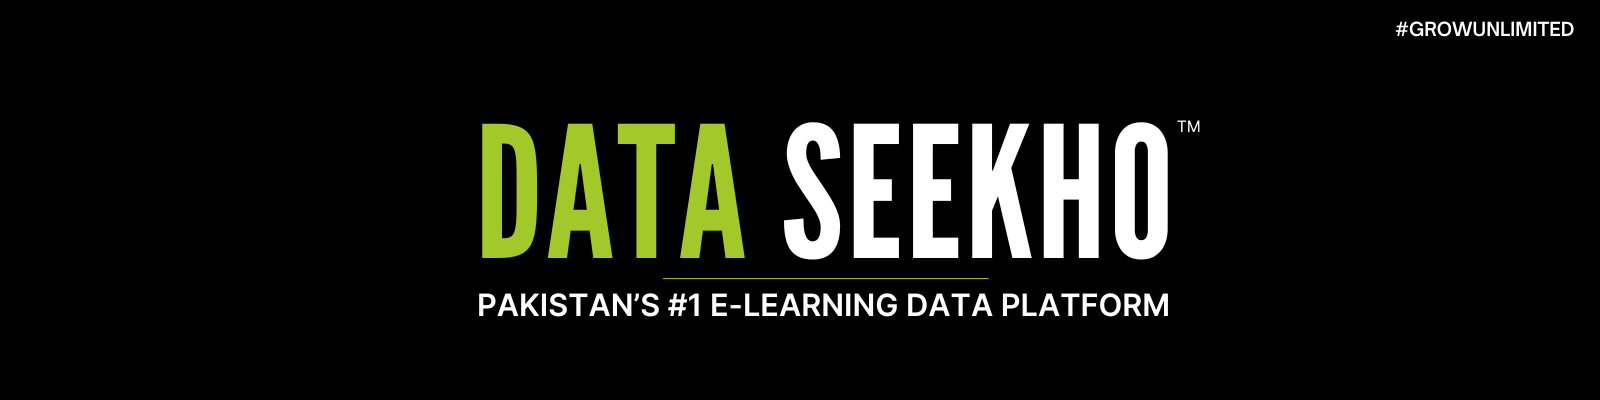

### 🚀 My Short Introduction! 🎓

- **Laiba Abdullah** is an aspiring data professional at **Data Seekho**.
- 📚 Learning **Python, SQL, Machine Learning**, and more through **Data Seekho’s** courses.
- 💻 Engaging in **hands-on projects** and learning from **industry experts**.
- 🌟 Part of **Data Seekho’s supportive community**, aiming for top 1% in data.
- 🎯 Preparing for a **successful career** in Data Science with **Data Seekho**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Step 2: Import Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Step 3: Load Datasets from Google Drive
# Replace these paths with the correct paths to your dataset files in Google Drive
orders_file = '/content/drive/MyDrive/Colab Notebooks/sqldata/Orders_Large.csv'
products_file = '/content/drive/MyDrive/Colab Notebooks/sqldata/Products_Large.csv'
customers_file = '/content/drive/MyDrive/Colab Notebooks/sqldata/Customers_Large.csv'
sales_file = '/content/drive/MyDrive/Colab Notebooks/sqldata/Sales_Large.csv'

In [6]:
# Load datasets into Pandas
orders = pd.read_csv(orders_file)
products = pd.read_csv(products_file)
customers = pd.read_csv(customers_file)
sales = pd.read_csv(sales_file)

In [7]:
# Step 4: Data Cleaning and Preprocessing
# Standardize column names to avoid SQL query issues
orders.columns = orders.columns.str.strip().str.replace(' ', '').str.replace('_', '')
products.columns = products.columns.str.strip().str.replace(' ', '').str.replace('_', '')
customers.columns = customers.columns.str.strip().str.replace(' ', '').str.replace('_', '')
sales.columns = sales.columns.str.strip().str.replace(' ', '').str.replace('_', '')

In [8]:
# Ensure OrderDate is in a valid datetime format
orders['OrderDate'] = pd.to_datetime(orders['OrderDate'], errors='coerce')
orders.dropna(subset=['OrderDate'], inplace=True)  # Remove invalid dates

In [9]:
# Step 5: Create SQLite Database and Load Data
conn = sqlite3.connect('ecommerce.db')

In [10]:
# Load Pandas DataFrames into SQLite tables
orders.to_sql('Orders', conn, index=False, if_exists='replace')
products.to_sql('Products', conn, index=False, if_exists='replace')
customers.to_sql('Customers', conn, index=False, if_exists='replace')
sales.to_sql('Sales', conn, index=False, if_exists='replace')

500

In [11]:
# Verify tables in the database
print(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn))

        name
0     Orders
1   Products
2  Customers
3      Sales


In [12]:
# Step 6: SQL Queries for Insights

# 6.1 Total Sales Revenue by Month
query_monthly_revenue = """
SELECT strftime('%Y-%m', OrderDate) AS Month, SUM(TotalAmount) AS Total_Revenue
FROM Orders
GROUP BY Month
ORDER BY Month;
"""
monthly_revenue = pd.read_sql_query(query_monthly_revenue, conn)
print(monthly_revenue)

      Month  Total_Revenue
0   2022-11           5333
1   2022-12          11504
2   2023-01          10761
3   2023-02           7856
4   2023-03           9450
5   2023-04          12112
6   2023-05          14227
7   2023-06          11111
8   2023-07          11378
9   2023-08          12551
10  2023-09          10301
11  2023-10           9660
12  2023-11           8420
13  2023-12          11972
14  2024-01          12408
15  2024-02           6815
16  2024-03          10996
17  2024-04           9552
18  2024-05          15866
19  2024-06          11178
20  2024-07          13125
21  2024-08          11182
22  2024-09          11523
23  2024-10          11019
24  2024-11           5377


In [13]:
# 6.2 Top 5 Best-Selling Products
query_top_products = """
SELECT Products.ProductName, SUM(Orders.Quantity) AS Total_Quantity
FROM Orders
JOIN Products ON Orders.ProductID = Products.ProductID
GROUP BY Products.ProductName
ORDER BY Total_Quantity DESC
LIMIT 5;
"""
top_products = pd.read_sql_query(query_top_products, conn)
print(top_products)

  ProductName  Total_Quantity
0      Notice             150
1        Card              99
2          We              96
3        Size              84
4        Both              81


In [14]:
# 6.3 Revenue Contribution by Customer Segments
query_segment_revenue = """
SELECT Customers.Segment, SUM(Orders.TotalAmount) AS Total_Revenue
FROM Orders
JOIN Customers ON Orders.CustomerID = Customers.CustomerID
GROUP BY Customers.Segment
ORDER BY Total_Revenue DESC;
"""
segment_revenue = pd.read_sql_query(query_segment_revenue, conn)
print(segment_revenue)


     Segment  Total_Revenue
0  Corporate         117980
1  Wholesale          74595
2     Retail          73102


In [15]:
# 6.4 Top Regions for Sales
query_region_sales = """
SELECT Customers.Region, SUM(Orders.TotalAmount) AS Total_Revenue
FROM Orders
JOIN Customers ON Orders.CustomerID = Customers.CustomerID
GROUP BY Customers.Region
ORDER BY Total_Revenue DESC;
"""
region_sales = pd.read_sql_query(query_region_sales, conn)
print(region_sales)

    Region  Total_Revenue
0     West          69494
1  Central          66744
2     East          58020
3    North          43118
4    South          28301


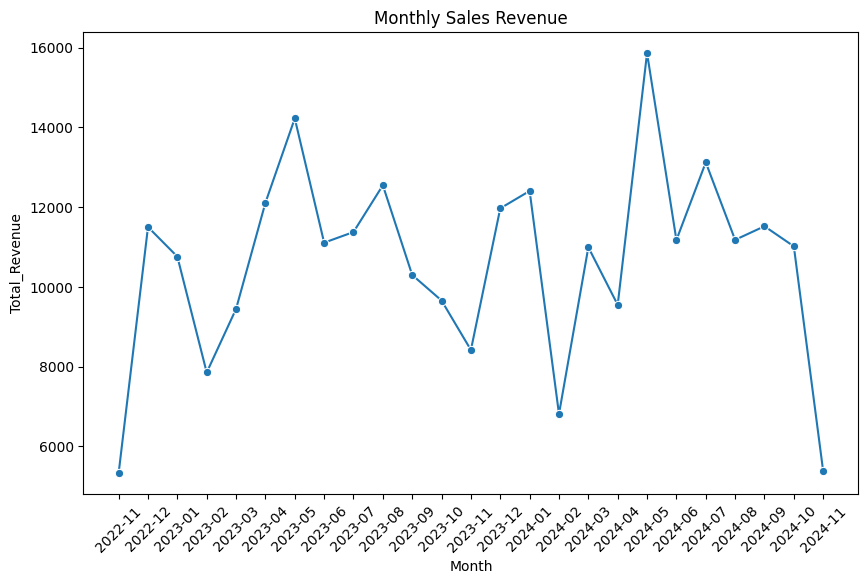

In [16]:
# Step 7: Visualizations

# 7.1 Monthly Sales Revenue
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='Month', y='Total_Revenue', marker='o')
plt.title('Monthly Sales Revenue')
plt.xticks(rotation=45)
plt.show()

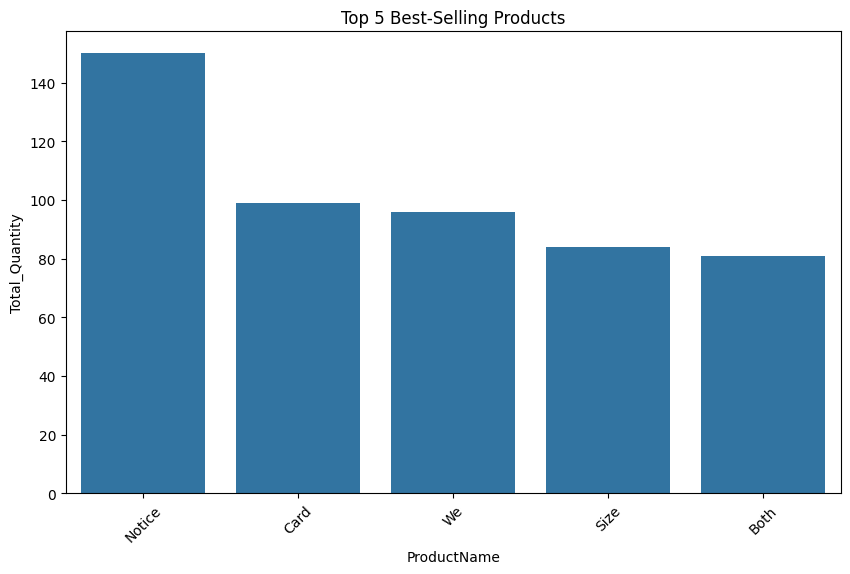

In [17]:
# 7.2 Top Products by Sales Quantity
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='ProductName', y='Total_Quantity')
plt.title('Top 5 Best-Selling Products')
plt.xticks(rotation=45)
plt.show()

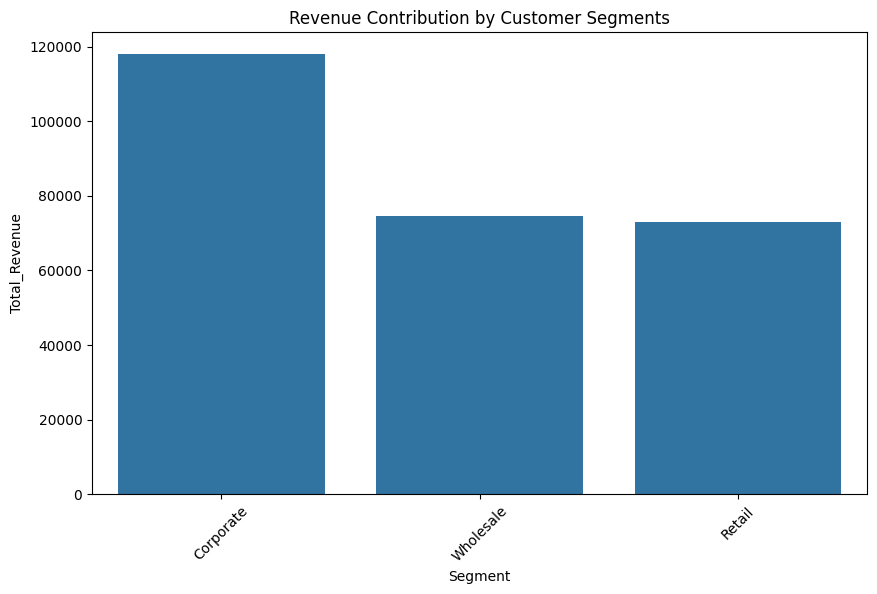

In [18]:
# 7.3 Revenue Contribution by Customer Segments
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_revenue, x='Segment', y='Total_Revenue')
plt.title('Revenue Contribution by Customer Segments')
plt.xticks(rotation=45)
plt.show()

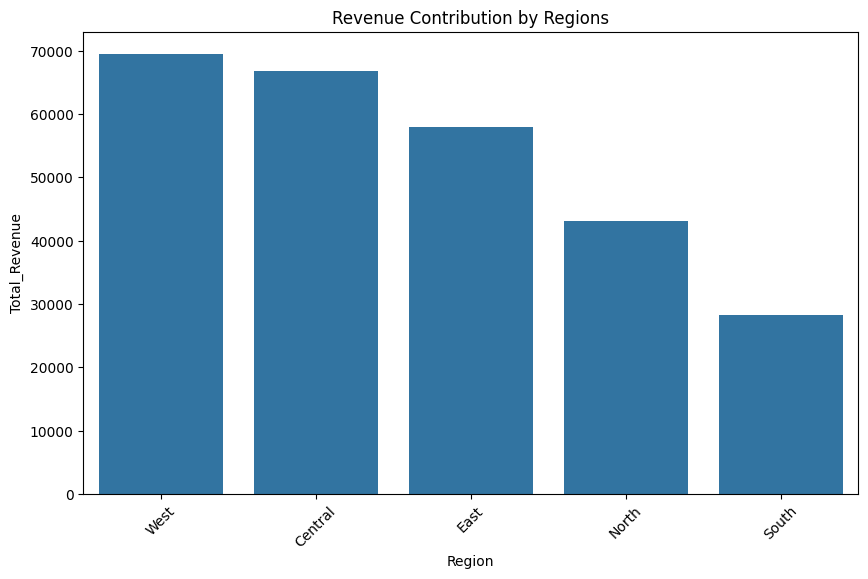

In [19]:
# 7.4 Revenue Contribution by Regions
plt.figure(figsize=(10, 6))
sns.barplot(data=region_sales, x='Region', y='Total_Revenue')
plt.title('Revenue Contribution by Regions')
plt.xticks(rotation=45)
plt.show()